In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

We import ready-made tools that have already been developed by other programmers.

In [6]:
df = pd.read_csv('ds_salaries.csv')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


To examine the structure of the dataset

In [8]:
df = df.drop(columns=['Unnamed: 0'])

Dropping an unnecessary column

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary              607 non-null    int64 
 5   salary_currency     607 non-null    object
 6   salary_in_usd       607 non-null    int64 
 7   employee_residence  607 non-null    object
 8   remote_ratio        607 non-null    int64 
 9   company_location    607 non-null    object
 10  company_size        607 non-null    object
dtypes: int64(4), object(7)
memory usage: 52.3+ KB


Check successful

In [10]:
df['experience_level'].value_counts()

,count
experience_level,
SE,280
MI,213
EN,88
EX,26


In [11]:
df.groupby('experience_level')['salary_in_usd'].mean()

,salary_in_usd
experience_level,
EN,61643.318182
EX,199392.038462
MI,87996.056338
SE,138617.292857


In [13]:
df.groupby('employee_residence')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

,salary_in_usd
employee_residence,
MY,200000.000000
PR,160000.000000
US,149194.117470
NZ,125000.000000
CH,122346.000000
AU,108042.666667
RU,105750.000000
SG,104176.500000
JP,103537.714286


It is inconvenient to work with two-letter country codes because they are not always clear, so we convert them to full country names.

In [14]:
!pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 54.1 MB/s eta 0:00:00


In [15]:
import pycountry

In [16]:
def country_full_name(code):
    try:
        return pycountry.countries.get(alpha_2=code).name
    except:
        return code

In [17]:
df['employee_residence'] = df['employee_residence'].apply(country_full_name)

In [18]:
df['employee_residence'].head()

,employee_residence
0,Germany
1,Japan
2,United Kingdom
3,Honduras
4,United States


Checking country names

In [19]:
df.groupby('employee_residence')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

,salary_in_usd
employee_residence,
Malaysia,200000.000000
Puerto Rico,160000.000000
United States,149194.117470
New Zealand,125000.000000
Switzerland,122346.000000
Australia,108042.666667
Russian Federation,105750.000000
Singapore,104176.500000
Japan,103537.714286


The translation sounds much better like this

In [20]:
top_countries = df.groupby('employee_residence')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

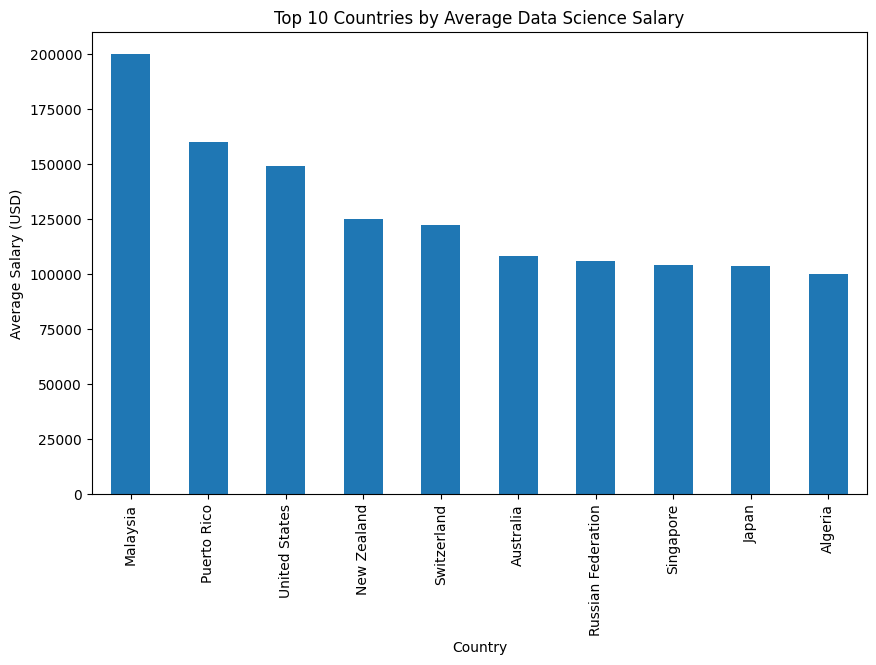

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Average Data Science Salary")
plt.xlabel("Country")
plt.ylabel("Average Salary (USD)")

plt.show()

**The analysis shows that salaries in the data science field are significantly higher in some countries.
The United States and several developed countries are among the locations with the highest salaries.**


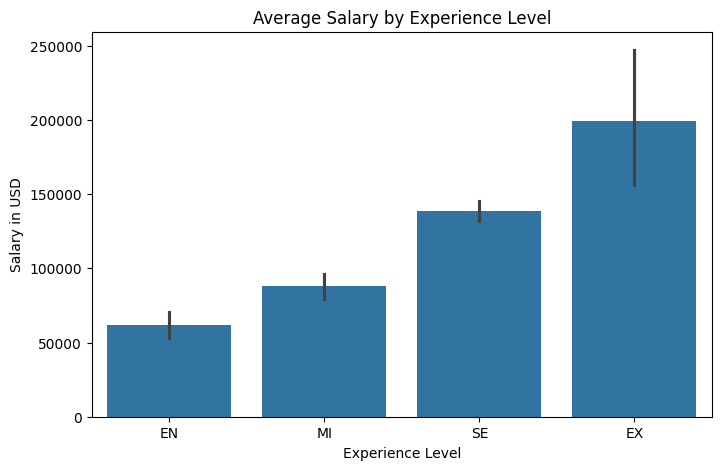

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='experience_level',
    y='salary_in_usd',
    data=df,
    order=['EN','MI','SE','EX']
)

plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary in USD")

plt.show()

Salary by Experience Level

/tmp/ipykernel_626/3414712166.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


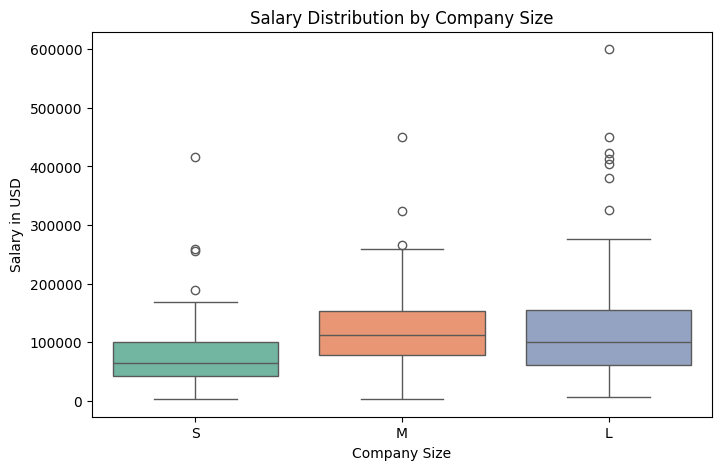

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='company_size',
    y='salary_in_usd',
    data=df,
    order=['S','M','L'],
    palette='Set2'
)

plt.title("Salary Distribution by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Salary in USD")

plt.show()



**Medium and large companies usually offer higher salaries, but the salary ranges still overlap.**


In [27]:
df['remote_ratio'].value_counts()

,count
remote_ratio,
100,381
0,127
50,99


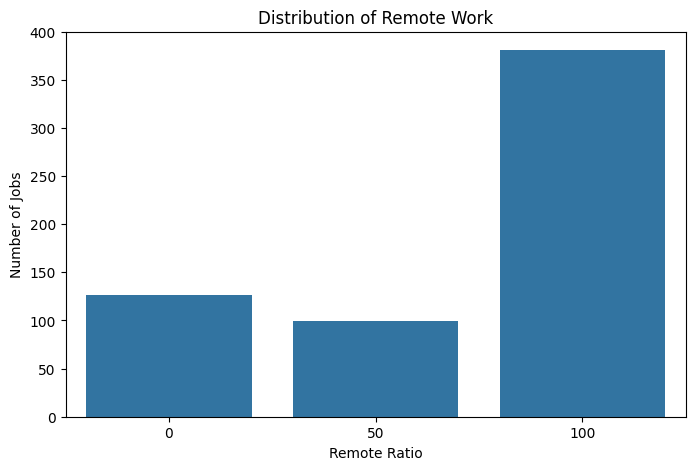

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(x='remote_ratio', data=df)

plt.title("Distribution of Remote Work")
plt.xlabel("Remote Ratio")
plt.ylabel("Number of Jobs")

plt.show()

A significant portion of data science jobs allow remote work.
Fully remote positions appear quite frequently in this dataset.

0 = On-site work
50 = Hybrid work
100 = Fully remote work

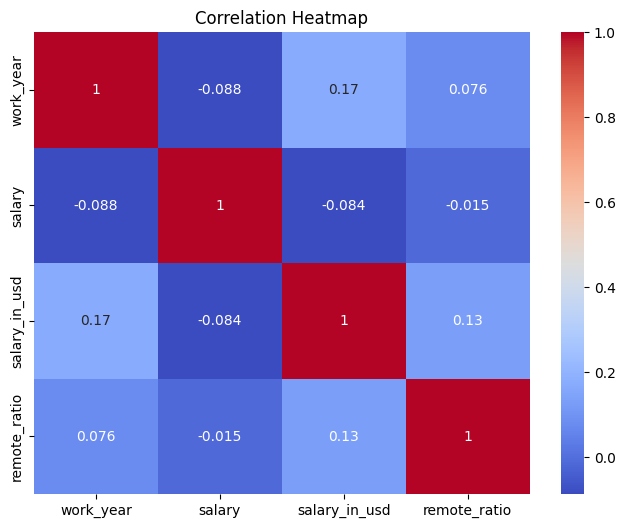

In [29]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Most numeric variables show weak correlations with each other.
Remote work ratio and work year do not strongly influence salaries in the dataset.

1. Salaries increase significantly with experience level.
2. Executive-level positions earn the highest salaries.
3. Some countries offer higher salaries for data science roles.
4. Medium and large companies tend to pay higher salaries.
5. Remote work does not strongly affect salary levels in the dataset.